In [3]:
import os
import sys
import json
import warnings
import time

# Add project root to path
sys.path.insert(0, './')

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Core imports
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats as sp_stats

# Project-specific imports
from main.config_vae import ConfigPoisVAE, ConfigTrainVAE
from main.vae import PoissonVAE
from main.train_vae import TrainerVAE
from base.dataset import make_dataset, make_dataloader
from base.distributions import Poisson
from utils.plotting import set_style, create_figure
from analysis.eval import sparse_score, knn_analysis
from analysis.clf import clf_analysis

# Set plotting style
%matplotlib inline
set_style()

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.9.1+cu128
CUDA available: True


In [4]:
# Configuration for lin|lin architecture
MODEL_NAME = "poisson_lin_lin"
DATA_DIR = "Datasets"
DATASET = "vH16"
DEVICE_IDX = 0
DEVICE = f"cuda:{DEVICE_IDX}" if torch.cuda.is_available() else "cpu"
CHECKPOINT_DIR = "./checkpoints"

# Model config - linear encoder, linear decoder
PRIOR_CLAMP = -4
PRIOR_LOG_DIST = "uniform"
HARD_FWD = False
EXC_ONLY = False
RMAX_Q = 1.0
N_CH = 32
N_LATENTS = 512
ENC_TYPE = "lin"  # Linear encoder
DEC_TYPE = "lin"  # Linear decoder
ENC_BIAS = False
DEC_BIAS = False
ENC_NORM = False
DEC_NORM = False
FIT_PRIOR = True
ACTIVATION_FN = "swish"
INIT_DIST = "Normal"
INIT_SCALE = 0.0001
RES_EPS = 1.0
USE_BN = False
USE_SE = True
SEED = 0

# Training config
METHOD = "mc"
KL_BETA = 1.0
KL_BETA_MIN = 0.0001
KL_ANNEAL_CYCLES = 0
KL_ANNEAL_PORTION = 0.5
KL_CONST_PORTION = 0.0
LAMBDA_ANNEAL = False
LAMBDA_INIT = 0.0
LAMBDA_NORM = 0.0
TEMP_ANNEAL_PORTION = 0.5
TEMP_ANNEAL_TYPE = "lin"
TEMP_START = 1.0
TEMP_STOP = 0.05
LEARNING_RATE = 0.005
EPOCHS = 3000
BATCH_SIZE = 1000
WARM_RESTART = 0
WARMUP_EPOCHS = 5
OPTIMIZER = "adamax_fast"
OPTIMIZER_KWS = {"weight_decay": 0.0, "betas": [0.9, 0.999], "eps": 1e-08}
SCHEDULER_TYPE = "cosine"
SCHEDULER_KWS = {"T_max": 2995.0, "eta_min": 1e-05}
EMA_RATE = None
GRAD_CLIP = 500
USE_AMP = False
CHKPT_FREQ = EPOCHS  # Save only final checkpoint (set to EPOCHS)
EVAL_FREQ = 20
LOG_FREQ = 10

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"Configuration loaded!")
print(f"  Model: {MODEL_NAME}")
print(f"  Device: {DEVICE}")
print(f"  Dataset: {DATASET}")
print(f"  Architecture: {ENC_TYPE}|{DEC_TYPE}")
print(f"  Latent dims: {N_LATENTS}")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")

Configuration loaded!
  Model: poisson_lin_lin
  Device: cuda:0
  Dataset: vH16
  Architecture: lin|lin
  Latent dims: 512
  Epochs: 3000
  Batch size: 1000
  Learning rate: 0.005


In [5]:
# Verify GPU availability and setup
if torch.cuda.is_available():
    print(f"✓ CUDA is available")
    print(f"  GPU count: {torch.cuda.device_count()}")
    print(f"  Current device: {torch.cuda.current_device()}")
    print(f"  Device name: {torch.cuda.get_device_name(DEVICE_IDX)}")
    print(f"  Memory allocated: {torch.cuda.memory_allocated(DEVICE_IDX) / 1e9:.2f} GB")
    print(f"  Memory cached: {torch.cuda.memory_reserved(DEVICE_IDX) / 1e9:.2f} GB")
else:
    print("✗ CUDA is NOT available. Training will run on CPU (much slower).")
    print("  Consider installing CUDA toolkit and PyTorch with CUDA support.")

# Set device
device = torch.device(DEVICE)
print(f"\nUsing device: {device}")

✓ CUDA is available
  GPU count: 4
  Current device: 0
  Device name: NVIDIA RTX 6000 Ada Generation
  Memory allocated: 0.00 GB
  Memory cached: 0.00 GB

Using device: cuda:0


In [6]:
# Load dataset
print(f"Loading {DATASET} dataset from {DATA_DIR}...")

trn_data, vld_data, tst_data = make_dataset(
    dataset=DATASET,
    device=device,
    load_dir=DATA_DIR,
)

# Create dataloaders
dl_trn = torch.utils.data.DataLoader(
    trn_data, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    drop_last=True
)
dl_vld = torch.utils.data.DataLoader(
    vld_data, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    drop_last=False
)

print(f"✓ Dataset loaded successfully!")
print(f"  Training samples: {len(trn_data)}")
print(f"  Validation samples: {len(vld_data)}")
print(f"  Training batches: {len(dl_trn)}")
print(f"  Batch size: {BATCH_SIZE}")

Loading vH16 dataset from Datasets...
✓ Dataset loaded successfully!
  Training samples: 80000
  Validation samples: 20000
  Training batches: 80
  Batch size: 1000


In [7]:
# Create model configuration matching reference
# Override base_dir to use simple checkpoint structure
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, MODEL_NAME)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

model_cfg = ConfigPoisVAE(
    prior_clamp=PRIOR_CLAMP,
    prior_log_dist=PRIOR_LOG_DIST,
    hard_fwd=HARD_FWD,
    exc_only=EXC_ONLY,
    rmax_q=RMAX_Q,
    dataset=DATASET,
    n_ch=N_CH,
    n_latents=N_LATENTS,
    enc_type=ENC_TYPE,
    dec_type=DEC_TYPE,
    enc_bias=ENC_BIAS,
    dec_bias=DEC_BIAS,
    enc_norm=ENC_NORM,
    dec_norm=DEC_NORM,
    fit_prior=FIT_PRIOR,
    activation_fn=ACTIVATION_FN,
    init_dist=INIT_DIST,
    init_scale=INIT_SCALE,
    res_eps=RES_EPS,
    use_bn=USE_BN,
    use_se=USE_SE,
    seed=SEED,
    save=False,
    base_dir=CHECKPOINT_DIR,
    data_dir=DATA_DIR,
)

# Override the mods_dir to use simple structure
model_cfg.mods_dir = CHECKPOINT_PATH

print(f"Model Config: {model_cfg.type}")
print(f"  Dataset: {model_cfg.dataset}, size: {model_cfg.input_sz}x{model_cfg.input_sz}")
print(f"  Architecture: {model_cfg.enc_type}|{model_cfg.dec_type}")
print(f"  Latents: {model_cfg.n_latents}, Channels: {model_cfg.n_ch}")
print(f"  Prior clamp: {model_cfg.prior_clamp}")
print(f"  Checkpoint dir: {CHECKPOINT_PATH}")

Model Config: poisson
  Dataset: vH16, size: 16x16
  Architecture: lin|lin
  Latents: 512, Channels: 32
  Prior clamp: -4
  Checkpoint dir: ./checkpoints/poisson_lin_lin


In [8]:
# Create training configuration matching reference
train_cfg = ConfigTrainVAE(
    method=METHOD,
    kl_beta=KL_BETA,
    kl_beta_min=KL_BETA_MIN,
    kl_anneal_cycles=KL_ANNEAL_CYCLES,
    kl_anneal_portion=KL_ANNEAL_PORTION,
    kl_const_portion=KL_CONST_PORTION,
    lambda_anneal=LAMBDA_ANNEAL,
    lambda_init=LAMBDA_INIT,
    lambda_norm=LAMBDA_NORM,
    temp_anneal_portion=TEMP_ANNEAL_PORTION,
    temp_anneal_type=TEMP_ANNEAL_TYPE,
    temp_start=TEMP_START,
    temp_stop=TEMP_STOP,
    lr=LEARNING_RATE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    warm_restart=WARM_RESTART,
    warmup_epochs=WARMUP_EPOCHS,
    optimizer=OPTIMIZER,
    optimizer_kws=OPTIMIZER_KWS,
    scheduler_type=SCHEDULER_TYPE,
    scheduler_kws=SCHEDULER_KWS,
    ema_rate=EMA_RATE,
    grad_clip=GRAD_CLIP,
    use_amp=USE_AMP,
    chkpt_freq=CHKPT_FREQ,
    eval_freq=EVAL_FREQ,
    log_freq=LOG_FREQ,
)

print(f"Training Config:")
print(f"  Method: {train_cfg.method}")
print(f"  Epochs: {train_cfg.epochs}, Batch size: {train_cfg.batch_size}")
print(f"  LR: {train_cfg.lr}, Optimizer: {train_cfg.optimizer}")
print(f"  Temperature: {train_cfg.temp_start} -> {train_cfg.temp_stop}")
print(f"  KL beta: {train_cfg.kl_beta}")

Training Config:
  Method: mc
  Epochs: 3000, Batch size: 1000
  LR: 0.005, Optimizer: adamax_fast
  Temperature: 1.0 -> 0.05
  KL beta: 1.0


In [9]:
# Initialize the Poisson VAE model
model = PoissonVAE(model_cfg)
model = model.to(device)

# Override the create_chkpt_dir method to use simple directory
def simple_chkpt_dir(self, fit_name=None):
    self.chkpt_dir = CHECKPOINT_PATH
    os.makedirs(self.chkpt_dir, exist_ok=True)

model.create_chkpt_dir = lambda fit_name=None: simple_chkpt_dir(model, fit_name)

# Count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Model initialized on {device}")
print(f"  Trainable parameters: {n_params:,}")

# Show model architecture summary
print(f"\nModel Architecture:")
print(f"  Encoder output: {model._enc_out_channel()} features")
print(f"  Decoder input: {model._dec_in_channel()} features")
print(f"  Output shape: {model.shape}")

✓ Model initialized on cuda:0
  Trainable parameters: 262,656

Model Architecture:
  Encoder output: 512 features
  Decoder input: 512 features
  Output shape: (-1, 1, 16, 16)


In [10]:
# Load checkpoint
from pathlib import Path

checkpoint_dir = Path(CHECKPOINT_PATH)
checkpoint_files = sorted(checkpoint_dir.glob("PoissonVAE+TrainerVAE-*.pt"))

if checkpoint_files:
    checkpoint_file = checkpoint_files[-1]  # Load latest
    print(f"Loading checkpoint: {checkpoint_file.name}")
    
    checkpoint = torch.load(checkpoint_file, map_location=device, weights_only=False)
    
    # Handle different checkpoint formats
    if isinstance(checkpoint, dict):
        if 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        elif 'model' in checkpoint:
            model.load_state_dict(checkpoint['model'])
        else:
            model.load_state_dict(checkpoint)
    else:
        model.load_state_dict(checkpoint)
    
    print(f"✓ Checkpoint loaded successfully")
    print(f"  File size: {checkpoint_file.stat().st_size / 1024 / 1024:.1f} MB")
else:
    print(f"⚠ No checkpoint found in {CHECKPOINT_PATH}")

Loading checkpoint: PoissonVAE+TrainerVAE-3000_(2024_11_28,15:26).pt
✓ Checkpoint loaded successfully
  File size: 21.0 MB


In [56]:
# Initialize trainer
trainer = TrainerVAE(
    model=model,
    cfg=train_cfg,
    device=device,
    verbose=True,
)

print(f"✓ Trainer initialized")
print(f"  Total iterations: {trainer.n_iters}")
print(f"  Iterations per epoch: {len(trainer.dl_trn)}")


# params: 1.4 M
✓ Trainer initialized
  Total iterations: 240000
  Iterations per epoch: 80


In [58]:
# Train the model
print(f"Starting training...")
print(f"  Architecture: {ENC_TYPE}|{DEC_TYPE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Device: {DEVICE}")
print(f"  Checkpoint dir: {CHECKPOINT_PATH}")
print()

trainer.train(
    epochs=EPOCHS,
    fresh_fit=True,
    save=True
)

print("\n✓ Training completed!")

Starting training...
  Architecture: conv|lin
  Epochs: 3000
  Device: cuda:0
  Checkpoint dir: ./checkpoints/poisson_conv_lin



epoch # 3000, avg loss: 173.582130: 100%|██████████| 3000/3000 [4:19:25<00:00,  5.19s/it]  


✓ Training completed!


In [68]:
# Checkpoint Cleanup
import os
from pathlib import Path

print("="*80)
print("CHECKPOINT CLEANUP")
print("="*80)

# Remove old checkpoints, keep only the latest
checkpoint_dir = Path(CHECKPOINT_PATH)
if checkpoint_dir.exists():
    checkpoint_files = sorted(checkpoint_dir.glob("PoissonVAE+TrainerVAE-*.pt"))
    
    if len(checkpoint_files) > 1:
        print(f"\nFound {len(checkpoint_files)} checkpoint files")
        print(f"Removing {len(checkpoint_files) - 1} old checkpoints...")
        
        # Keep only the last checkpoint
        for ckpt in checkpoint_files[:-1]:
            ckpt.unlink()
            print(f"  Deleted: {ckpt.name}")
        
        print(f"\n✓ Kept only latest checkpoint: {checkpoint_files[-1].name}")
    else:
        print(f"\n✓ Only one checkpoint found (already clean): {checkpoint_files[0].name if checkpoint_files else 'None'}")
    
    # Show final directory size
    total_size = sum(f.stat().st_size for f in checkpoint_dir.glob("*") if f.is_file())
    print(f"\nCheckpoint directory size: {total_size / 1024 / 1024:.1f} MB")
else:
    print(f"\n⚠ Checkpoint directory not found: {CHECKPOINT_PATH}")

print(f"\n{'='*80}")

CHECKPOINT CLEANUP

✓ Only one checkpoint found (already clean): PoissonVAE+TrainerVAE-3000_(2025_12_27,02:08).pt

Checkpoint directory size: 30.0 MB



TRAINING CURVES
Available metrics: ['grad', 'lr', 't', 'r_max', 'n_exp', 'eval/r2', 'eval/mse', 'eval/kl', 'eval/kl_diag', 'sprs/%-zero', 'sprs/lifetime', 'sprs/population']

Stats organized by epoch (dict format)


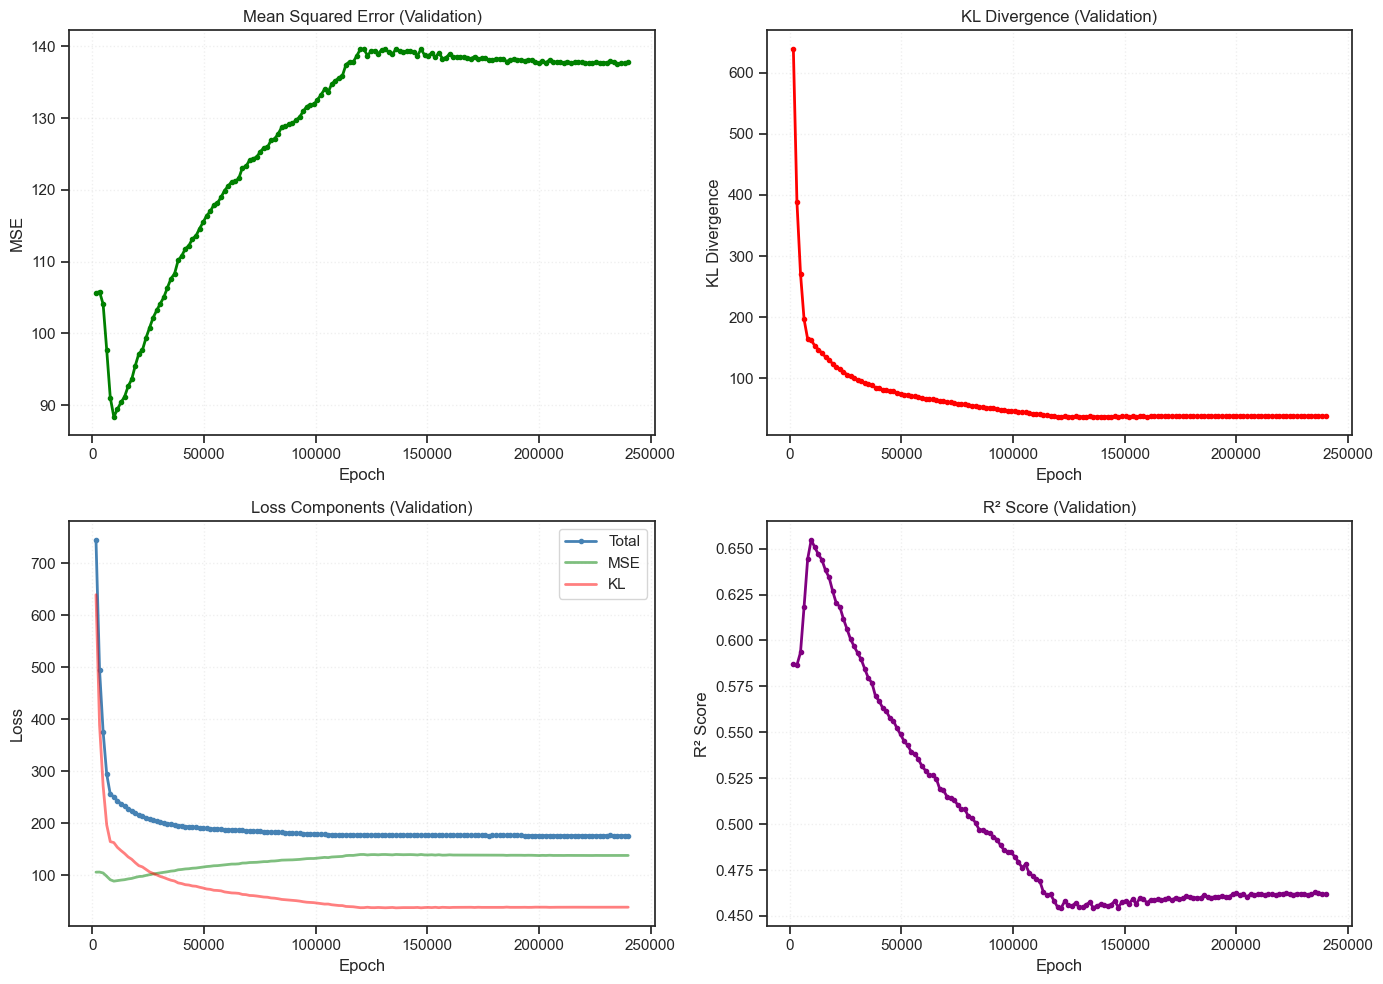


Final Validation Metrics:
  MSE: 137.79
  KL: 38.28
  Total Loss: 176.07



In [80]:
# Visualize Training Curves
import matplotlib.pyplot as plt
import numpy as np

print("="*80)
print("TRAINING CURVES")
print("="*80)

# Check if trainer has stats
if hasattr(trainer, 'stats') and len(trainer.stats) > 0:
    stats = trainer.stats
    
    # The stats are organized by metric name
    print(f"Available metrics: {list(stats.keys())}")
    
    # Check the structure of the data
    eval_mse = stats.get('eval/mse', None)
    
    # If the stats contain dict values (organized by epoch)
    if isinstance(eval_mse, dict):
        print("\nStats organized by epoch (dict format)")
        epochs = sorted([int(k) for k in eval_mse.keys() if str(k).isdigit()])
        
        if len(epochs) > 0:
            eval_mse_vals = [eval_mse[e] for e in epochs]
            eval_kl_vals = [stats['eval/kl'].get(e, np.nan) for e in epochs]
            eval_r2_vals = [stats.get('eval/r2', {}).get(e, np.nan) for e in epochs]
            
            # Create figure
            fig, axes = plt.subplots(2, 2, figsize=(14, 10))
            
            axes[0, 0].plot(epochs, eval_mse_vals, linewidth=2, color='green', marker='o', markersize=3)
            axes[0, 0].set_xlabel('Epoch')
            axes[0, 0].set_ylabel('MSE')
            axes[0, 0].set_title('Mean Squared Error (Validation)')
            axes[0, 0].grid(True, alpha=0.3)
            
            axes[0, 1].plot(epochs, eval_kl_vals, linewidth=2, color='red', marker='o', markersize=3)
            axes[0, 1].set_xlabel('Epoch')
            axes[0, 1].set_ylabel('KL Divergence')
            axes[0, 1].set_title('KL Divergence (Validation)')
            axes[0, 1].grid(True, alpha=0.3)
            
            total_loss = np.array(eval_mse_vals) + np.array(eval_kl_vals)
            axes[1, 0].plot(epochs, total_loss, linewidth=2, color='steelblue', marker='o', markersize=3, label='Total')
            axes[1, 0].plot(epochs, eval_mse_vals, linewidth=2, color='green', alpha=0.5, label='MSE')
            axes[1, 0].plot(epochs, eval_kl_vals, linewidth=2, color='red', alpha=0.5, label='KL')
            axes[1, 0].set_xlabel('Epoch')
            axes[1, 0].set_ylabel('Loss')
            axes[1, 0].set_title('Loss Components (Validation)')
            axes[1, 0].legend()
            axes[1, 0].grid(True, alpha=0.3)
            
            if not all(np.isnan(eval_r2_vals)):
                axes[1, 1].plot(epochs, eval_r2_vals, linewidth=2, color='purple', marker='o', markersize=3)
                axes[1, 1].set_xlabel('Epoch')
                axes[1, 1].set_ylabel('R² Score')
                axes[1, 1].set_title('R² Score (Validation)')
                axes[1, 1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            print(f"\nFinal Validation Metrics:")
            print(f"  MSE: {eval_mse_vals[-1]:.2f}")
            print(f"  KL: {eval_kl_vals[-1]:.2f}")
            print(f"  Total Loss: {total_loss[-1]:.2f}")
    
    # Otherwise, check if it's a single value (last value only)
    elif isinstance(eval_mse, (int, float, np.number)):
        print(f"\nStats contain only final values (not time series):")
        print(f"  eval/mse: {eval_mse:.2f}")
        print(f"  eval/kl: {stats.get('eval/kl', 'N/A'):.2f}")
        print(f"  eval/r2: {stats.get('eval/r2', 'N/A')}")
        print("\nNo training curve data available. Only final metrics were stored.")
    
    else:
        print(f"\nUnexpected stats format. Type of eval/mse: {type(eval_mse)}")
        print(f"Value: {eval_mse}")
        
        # Try to read from log file if available
        log_file = os.path.join(CHECKPOINT_PATH, 'TrainerVAE.log')
        if os.path.exists(log_file) and os.path.getsize(log_file) > 0:
            print(f"\nAttempting to parse training log: {log_file}")
            
            # Parse log file for loss values
            epochs_log = []
            losses_log = []
            
            with open(log_file, 'r') as f:
                for line in f:
                    # Look for lines like "epoch # 100, avg loss: 234.567"
                    if 'epoch #' in line and 'avg loss:' in line:
                        try:
                            parts = line.split(',')
                            epoch_str = parts[0].split('#')[1].strip()
                            loss_str = parts[1].split(':')[1].strip()
                            epochs_log.append(int(epoch_str))
                            losses_log.append(float(loss_str))
                        except:
                            continue
            
            if len(epochs_log) > 0:
                print(f"Found {len(epochs_log)} epoch entries in log file")
                
                # Create plot from log data
                fig, axes = plt.subplots(1, 2, figsize=(14, 5))
                
                axes[0].plot(epochs_log, losses_log, linewidth=2, color='steelblue')
                axes[0].set_xlabel('Epoch')
                axes[0].set_ylabel('Training Loss')
                axes[0].set_title('Training Loss Over Time (from log)')
                axes[0].grid(True, alpha=0.3)
                
                # Last 500 epochs
                n_last = min(500, len(epochs_log))
                axes[1].plot(epochs_log[-n_last:], losses_log[-n_last:], linewidth=2, color='steelblue')
                axes[1].set_xlabel('Epoch')
                axes[1].set_ylabel('Training Loss')
                axes[1].set_title(f'Training Loss (Last {n_last} Epochs)')
                axes[1].grid(True, alpha=0.3)
                
                plt.tight_layout()
                plt.show()
                
                print(f"\nTraining Summary (from log):")
                print(f"  Initial loss: {losses_log[0]:.2f}")
                print(f"  Final loss: {losses_log[-1]:.2f}")
                print(f"  Reduction: {losses_log[0] - losses_log[-1]:.2f} ({100*(losses_log[0]-losses_log[-1])/losses_log[0]:.1f}%)")
            else:
                print("Could not parse training curves from log file")
        else:
            print(f"\nLog file not found or empty: {log_file}")
else:
    print("No training statistics found in trainer.stats")

print(f"\n{'='*80}")

POST-TRAINING ANALYSIS

Validation Metrics:
  Negative ELBO: 227.85
  Reconstruction loss: 186.90
  KL divergence: 40.95

Active Neurons (KL > 0.01):
  Active: 505/512
  Proportion: 98.63%

Dead Neuron Detection (Histogram Method):
  Gap threshold: 0.0100
  Dead neurons: 7/512
  Dead proportion: 1.37%

Lifetime Sparsity:
  Overall: 0.7185 (71.85% of samples per neuron on average)
  Min: 0.0110
  Max: 1.0000
  Median: 0.7730


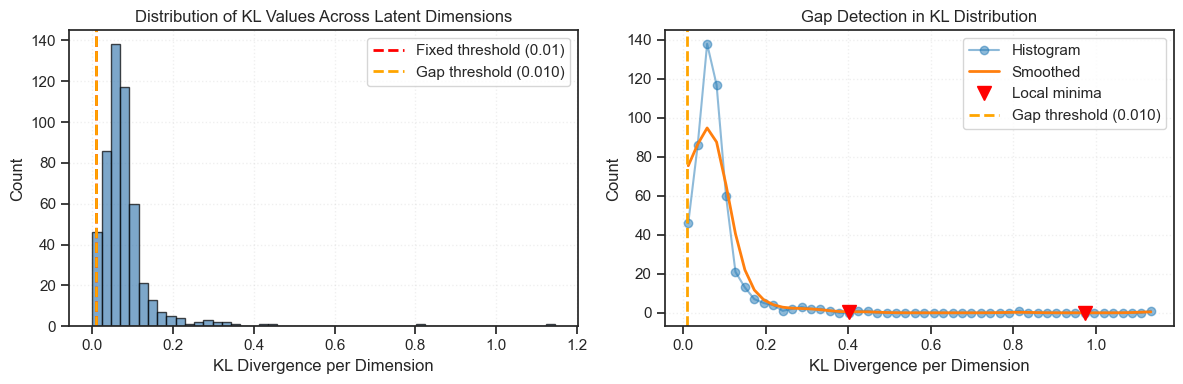

In [11]:
# Post-Training Analysis
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

print("="*80)
print("POST-TRAINING ANALYSIS")
print("="*80)

# Set model to eval mode and compute validation metrics
model.eval()
with torch.no_grad():
    # Get validation batch
    x_val = next(iter(dl_vld))[0].to(device)
    
    # Forward pass - returns (dist, log_dr, spks, y)
    dist, log_dr, spks, y = model(x_val)
    
    # Compute KL divergence per sample and dimension
    kl_diag = model.loss_kl(log_dr)  # Shape: (batch_size, n_latents)
    
    # Compute metrics
    mse = torch.mean((x_val - y)**2, dim=[1,2,3])
    kl_per_sample = torch.sum(kl_diag, dim=1)
    recon_loss = torch.mean(mse) * (model.cfg.input_sz ** 2)
    kl_loss = torch.mean(kl_per_sample)
    neg_elbo = recon_loss + kl_loss
    
    # Compute KL per latent dimension (average over samples)
    kl_per_dim = torch.mean(kl_diag, dim=0).cpu().numpy()
    
    print(f"\nValidation Metrics:")
    print(f"  Negative ELBO: {neg_elbo.item():.2f}")
    print(f"  Reconstruction loss: {recon_loss.item():.2f}")
    print(f"  KL divergence: {kl_loss.item():.2f}")

# Active neuron analysis
threshold = 0.01
active_mask = kl_per_dim > threshold
n_active = np.sum(active_mask)
n_total = len(kl_per_dim)
active_proportion = n_active / n_total

print(f"\nActive Neurons (KL > {threshold}):")
print(f"  Active: {n_active}/{n_total}")
print(f"  Proportion: {active_proportion:.2%}")

# Dead neuron detection using histogram method
# Bin the KL values and find the gap between small and large values
n_bins = 50
hist, bin_edges = np.histogram(kl_per_dim, bins=n_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Find the gap: look for the largest empty region in the histogram
# First, smooth the histogram slightly
from scipy.ndimage import gaussian_filter1d
smoothed_hist = gaussian_filter1d(hist.astype(float), sigma=1.5)

# Find local minima
from scipy.signal import argrelextrema
minima_idx = argrelextrema(smoothed_hist, np.less)[0]

# Find the minimum closest to zero (in the lower portion)
if len(minima_idx) > 0:
    # Look for minima in the first half of the distribution
    low_minima = minima_idx[bin_centers[minima_idx] < np.median(kl_per_dim)]
    if len(low_minima) > 0:
        gap_idx = low_minima[-1]  # Take the rightmost minimum in the low region
        gap_threshold = bin_centers[gap_idx]
    else:
        gap_threshold = threshold
else:
    gap_threshold = threshold

n_dead_histogram = np.sum(kl_per_dim < gap_threshold)

print(f"\nDead Neuron Detection (Histogram Method):")
print(f"  Gap threshold: {gap_threshold:.4f}")
print(f"  Dead neurons: {n_dead_histogram}/{n_total}")
print(f"  Dead proportion: {n_dead_histogram/n_total:.2%}")

# Compute lifetime sparsity
# Lifetime sparsity is the average proportion of times each neuron is active across the dataset
# A neuron is considered "active" on a sample if its spike count > 0
spks_np = spks.cpu().numpy()  # Shape: (batch_size, n_latents)
active_per_neuron = np.mean(spks_np > 0, axis=0)  # Average over samples
lifetime_sparsity = np.mean(active_per_neuron)  # Average over all neurons

print(f"\nLifetime Sparsity:")
print(f"  Overall: {lifetime_sparsity:.4f} ({lifetime_sparsity*100:.2f}% of samples per neuron on average)")
print(f"  Min: {active_per_neuron.min():.4f}")
print(f"  Max: {active_per_neuron.max():.4f}")
print(f"  Median: {np.median(active_per_neuron):.4f}")

# Plot KL distribution with thresholds
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(kl_per_dim, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Fixed threshold ({threshold})')
axes[0].axvline(gap_threshold, color='orange', linestyle='--', linewidth=2, label=f'Gap threshold ({gap_threshold:.3f})')
axes[0].set_xlabel('KL Divergence per Dimension')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of KL Values Across Latent Dimensions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Smoothed histogram with gap detection
axes[1].plot(bin_centers, hist, 'o-', alpha=0.5, label='Histogram')
axes[1].plot(bin_centers, smoothed_hist, linewidth=2, label='Smoothed')
if len(minima_idx) > 0:
    axes[1].plot(bin_centers[minima_idx], smoothed_hist[minima_idx], 'rv', 
                 markersize=10, label='Local minima')
axes[1].axvline(gap_threshold, color='orange', linestyle='--', linewidth=2, 
                label=f'Gap threshold ({gap_threshold:.3f})')
axes[1].set_xlabel('KL Divergence per Dimension')
axes[1].set_ylabel('Count')
axes[1].set_title('Gap Detection in KL Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")

RECONSTRUCTION VISUALIZATIONS

Reconstructed 32 validation samples
  Mean MSE: 0.7281
  Best MSE: 0.5755
  Worst MSE: 0.8587


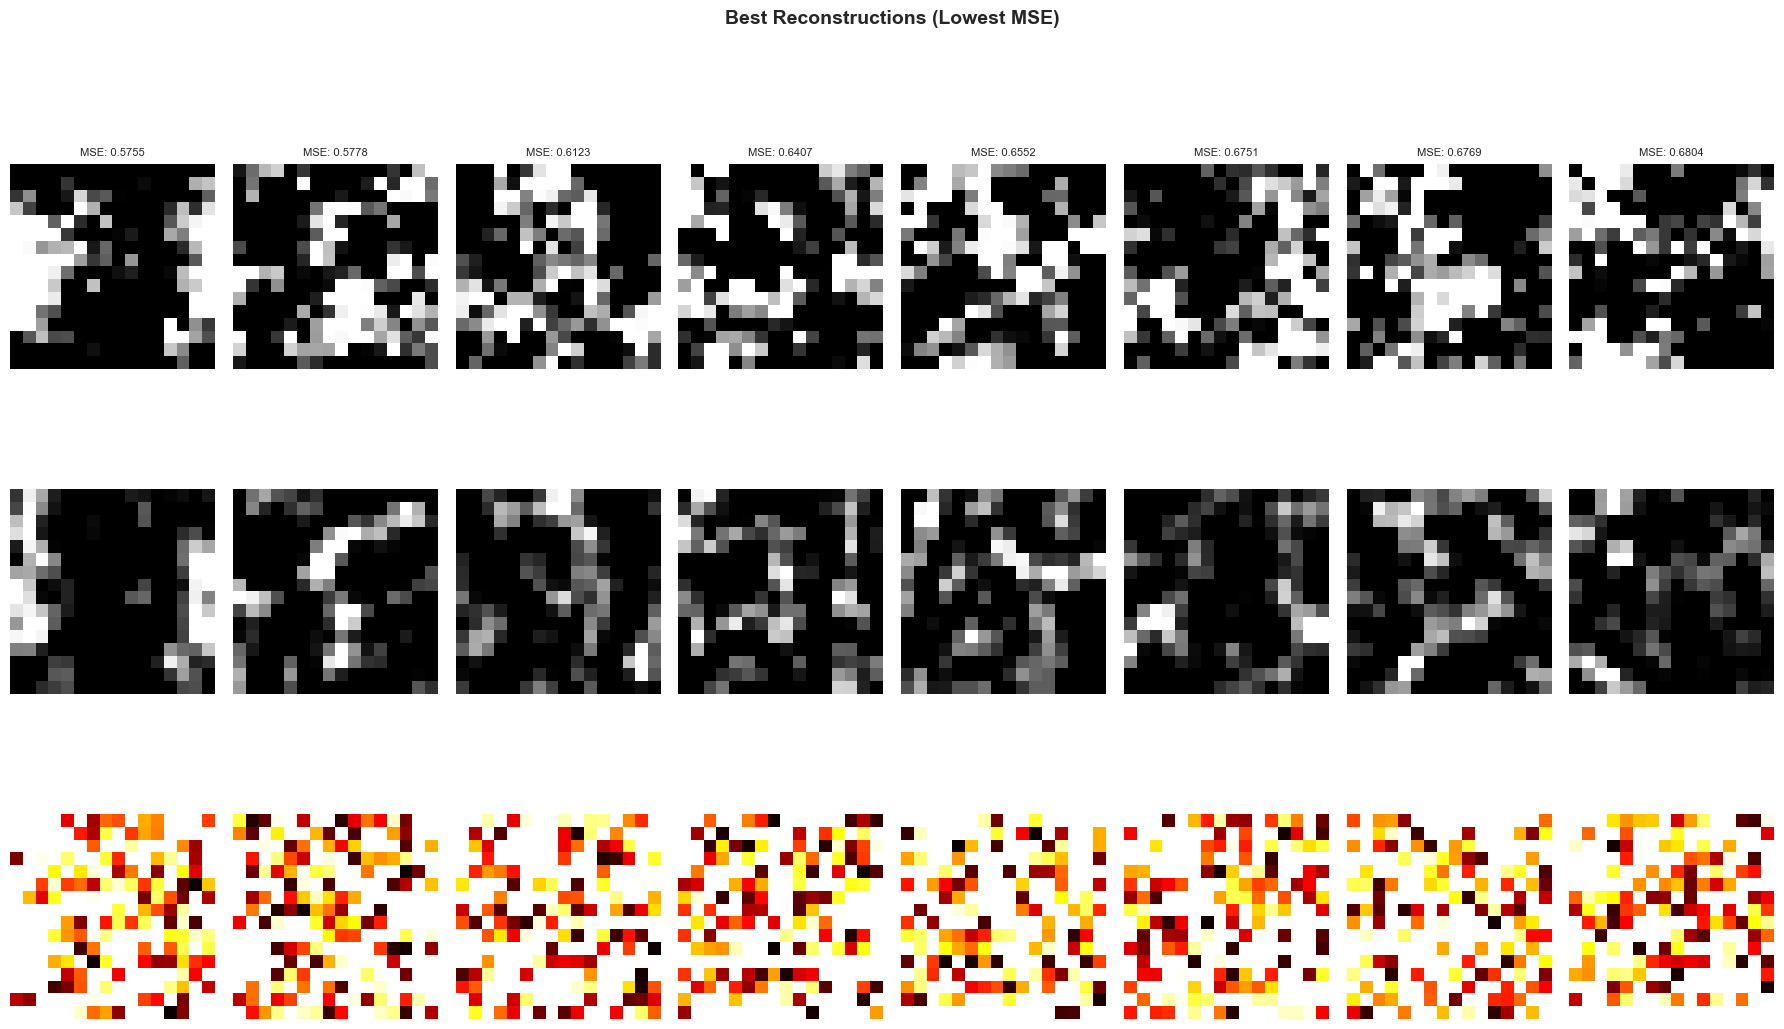

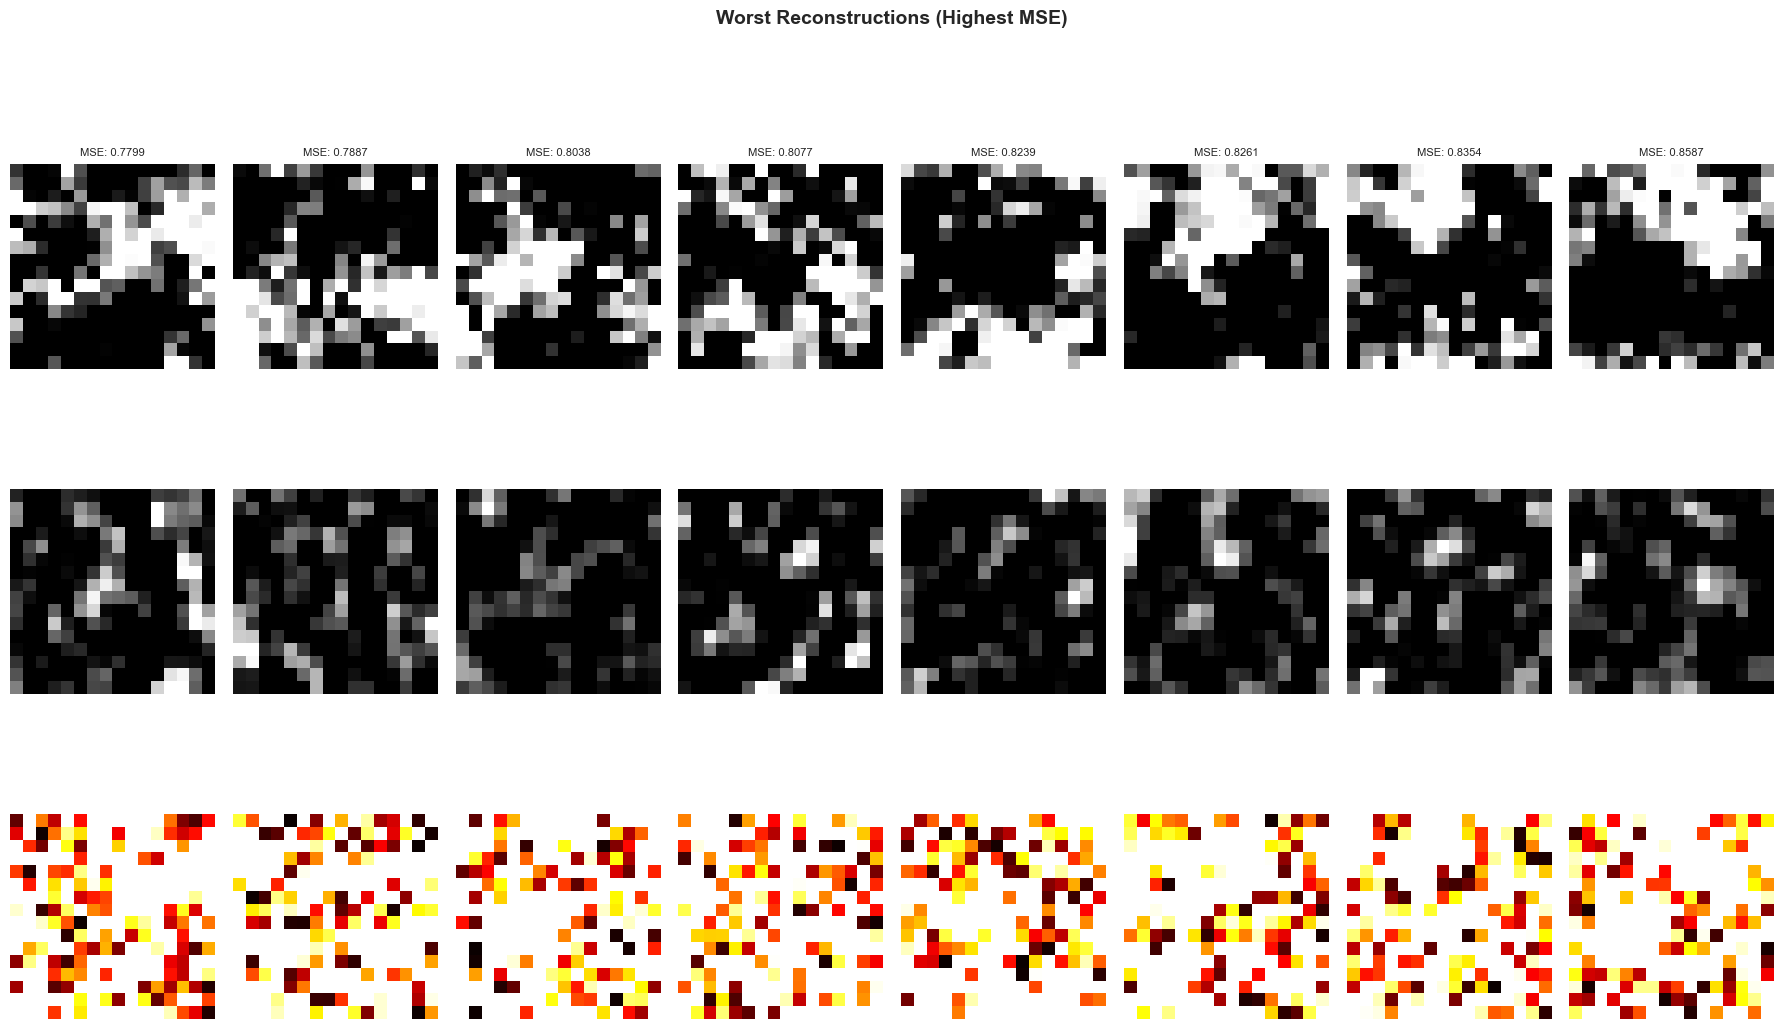

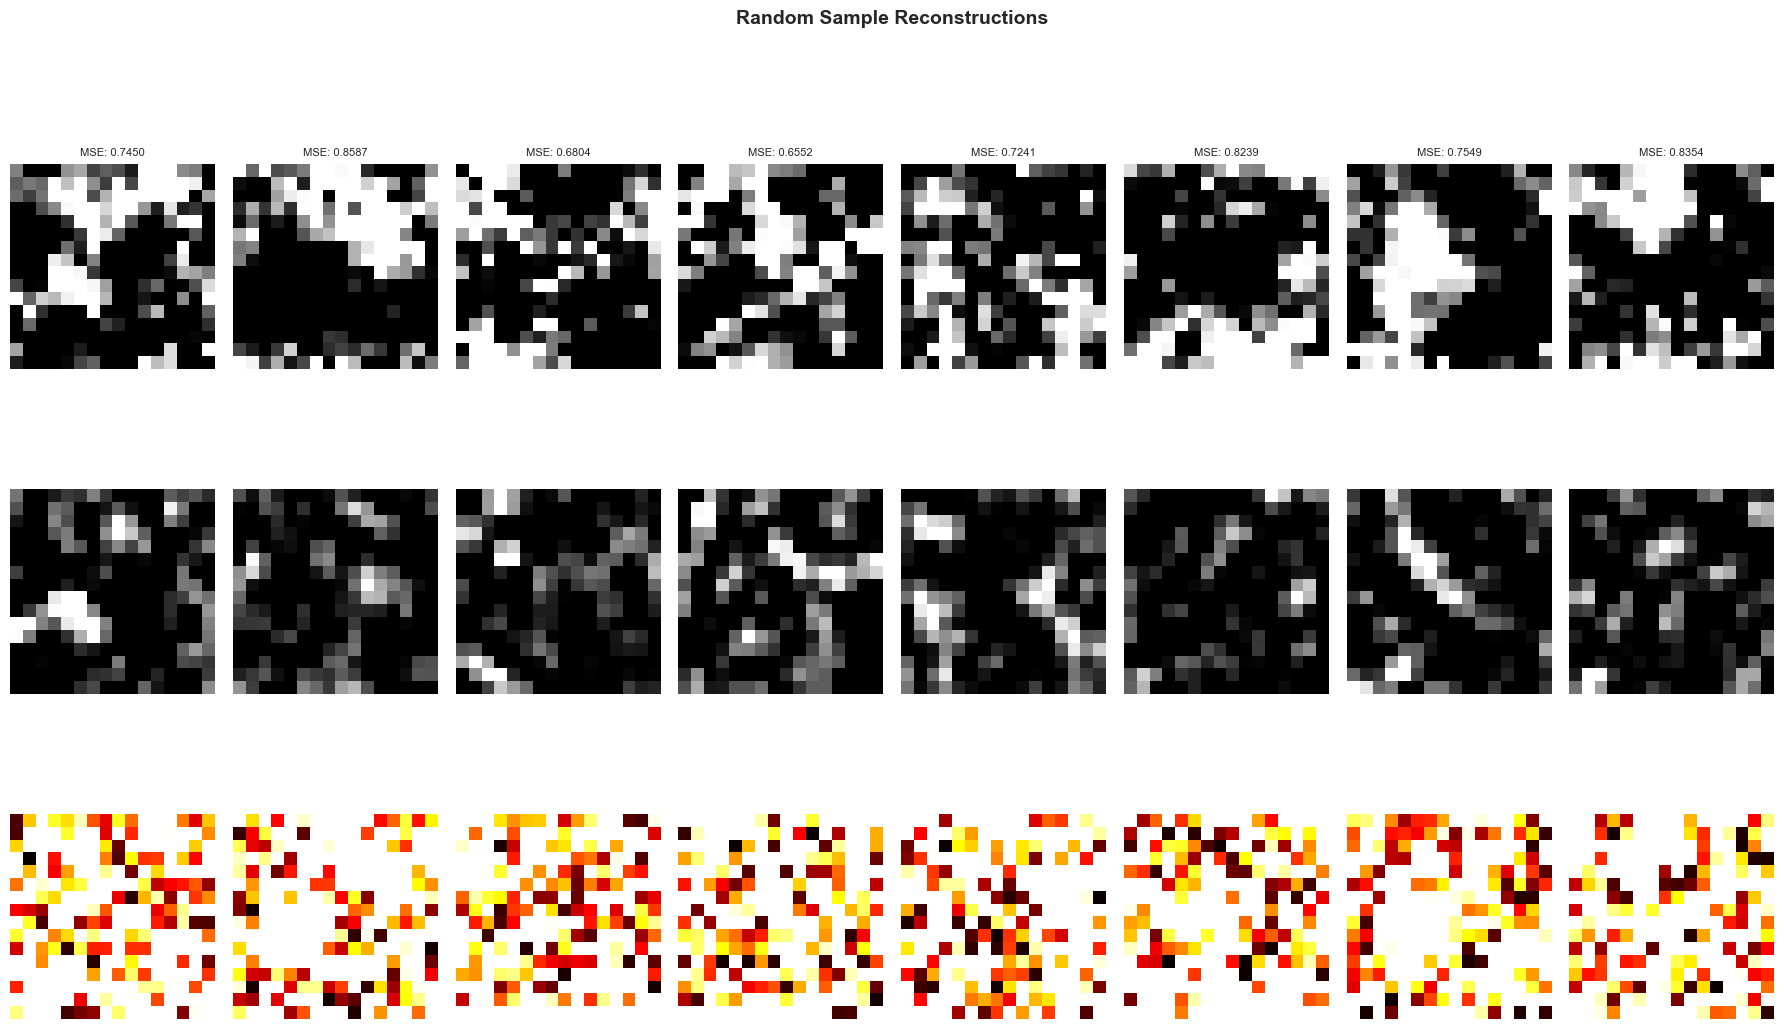


Reconstruction Quality Summary:
  MSE distribution:
    Min: 0.5755
    25th percentile: 0.6892
    Median: 0.7394
    75th percentile: 0.7717
    Max: 0.8587



In [75]:
# Reconstruction Visualizations
import matplotlib.pyplot as plt
import numpy as np

print("="*80)
print("RECONSTRUCTION VISUALIZATIONS")
print("="*80)

# Get a batch of validation samples
model.eval()
with torch.no_grad():
    # Sample multiple batches to get variety
    n_samples = 32  # Show 32 examples
    sample_indices = np.random.choice(len(vld_data), n_samples, replace=False)
    
    # Get the samples
    x_samples = torch.stack([vld_data[i][0] for i in sample_indices]).to(device)
    
    # Get reconstructions
    dist, log_dr, spks, y_recon = model(x_samples)
    
    # Move to CPU for visualization
    x_orig = x_samples.cpu().numpy().squeeze()
    y_recon = y_recon.cpu().numpy().squeeze()
    
    # Compute per-sample MSE
    mse_per_sample = np.mean((x_orig - y_recon)**2, axis=(1, 2))
    
    # Sort by reconstruction quality (best and worst)
    sorted_idx = np.argsort(mse_per_sample)
    best_idx = sorted_idx[:8]  # 8 best
    worst_idx = sorted_idx[-8:]  # 8 worst
    
    print(f"\nReconstructed {n_samples} validation samples")
    print(f"  Mean MSE: {np.mean(mse_per_sample):.4f}")
    print(f"  Best MSE: {mse_per_sample[best_idx[0]]:.4f}")
    print(f"  Worst MSE: {mse_per_sample[worst_idx[-1]]:.4f}")
    
    # Create visualization - show original, reconstruction, and difference
    fig = plt.figure(figsize=(18, 12))
    
    # Grid layout: 3 rows (original, reconstruction, difference) x 8 columns
    nrows = 3
    ncols = 8
    
    # Show best reconstructions
    fig.text(0.5, 0.95, 'Best Reconstructions (Lowest MSE)', 
             ha='center', va='top', fontsize=14, fontweight='bold')
    
    for i, idx in enumerate(best_idx):
        # Original
        ax = plt.subplot(nrows, ncols, i + 1)
        ax.imshow(x_orig[idx], cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'MSE: {mse_per_sample[idx]:.4f}', fontsize=8)
        ax.axis('off')
        if i == 0:
            ax.set_ylabel('Original', fontsize=10, rotation=0, ha='right', va='center')
        
        # Reconstruction
        ax = plt.subplot(nrows, ncols, ncols + i + 1)
        ax.imshow(y_recon[idx], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if i == 0:
            ax.set_ylabel('Recon', fontsize=10, rotation=0, ha='right', va='center')
        
        # Difference (error map)
        ax = plt.subplot(nrows, ncols, 2*ncols + i + 1)
        diff = np.abs(x_orig[idx] - y_recon[idx])
        im = ax.imshow(diff, cmap='hot', vmin=0, vmax=0.5)
        ax.axis('off')
        if i == 0:
            ax.set_ylabel('|Error|', fontsize=10, rotation=0, ha='right', va='center')
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()
    
    # Show worst reconstructions
    fig = plt.figure(figsize=(18, 12))
    
    fig.text(0.5, 0.95, 'Worst Reconstructions (Highest MSE)', 
             ha='center', va='top', fontsize=14, fontweight='bold')
    
    for i, idx in enumerate(worst_idx):
        # Original
        ax = plt.subplot(nrows, ncols, i + 1)
        ax.imshow(x_orig[idx], cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'MSE: {mse_per_sample[idx]:.4f}', fontsize=8)
        ax.axis('off')
        if i == 0:
            ax.set_ylabel('Original', fontsize=10, rotation=0, ha='right', va='center')
        
        # Reconstruction
        ax = plt.subplot(nrows, ncols, ncols + i + 1)
        ax.imshow(y_recon[idx], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if i == 0:
            ax.set_ylabel('Recon', fontsize=10, rotation=0, ha='right', va='center')
        
        # Difference (error map)
        ax = plt.subplot(nrows, ncols, 2*ncols + i + 1)
        diff = np.abs(x_orig[idx] - y_recon[idx])
        im = ax.imshow(diff, cmap='hot', vmin=0, vmax=0.5)
        ax.axis('off')
        if i == 0:
            ax.set_ylabel('|Error|', fontsize=10, rotation=0, ha='right', va='center')
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()
    
    # Show random samples for diversity
    fig = plt.figure(figsize=(18, 12))
    
    fig.text(0.5, 0.95, 'Random Sample Reconstructions', 
             ha='center', va='top', fontsize=14, fontweight='bold')
    
    random_idx = np.random.choice(n_samples, 8, replace=False)
    
    for i, idx in enumerate(random_idx):
        # Original
        ax = plt.subplot(nrows, ncols, i + 1)
        ax.imshow(x_orig[idx], cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'MSE: {mse_per_sample[idx]:.4f}', fontsize=8)
        ax.axis('off')
        if i == 0:
            ax.set_ylabel('Original', fontsize=10, rotation=0, ha='right', va='center')
        
        # Reconstruction
        ax = plt.subplot(nrows, ncols, ncols + i + 1)
        ax.imshow(y_recon[idx], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if i == 0:
            ax.set_ylabel('Recon', fontsize=10, rotation=0, ha='right', va='center')
        
        # Difference (error map)
        ax = plt.subplot(nrows, ncols, 2*ncols + i + 1)
        diff = np.abs(x_orig[idx] - y_recon[idx])
        im = ax.imshow(diff, cmap='hot', vmin=0, vmax=0.5)
        ax.axis('off')
        if i == 0:
            ax.set_ylabel('|Error|', fontsize=10, rotation=0, ha='right', va='center')
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()
    
    # Summary statistics
    print(f"\nReconstruction Quality Summary:")
    print(f"  MSE distribution:")
    print(f"    Min: {np.min(mse_per_sample):.4f}")
    print(f"    25th percentile: {np.percentile(mse_per_sample, 25):.4f}")
    print(f"    Median: {np.median(mse_per_sample):.4f}")
    print(f"    75th percentile: {np.percentile(mse_per_sample, 75):.4f}")
    print(f"    Max: {np.max(mse_per_sample):.4f}")

print(f"\n{'='*80}")

LEARNED BASIS ELEMENTS


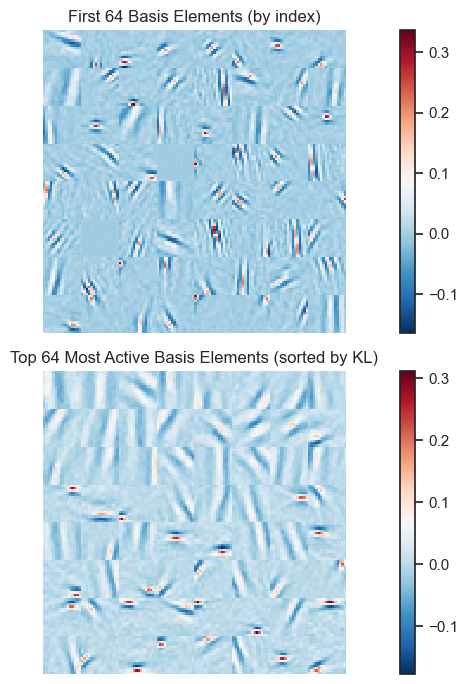


Basis Element Statistics:
  Total latent dimensions: 512
  Basis element shape: 16x16
  Weight range: [-0.201, 0.392]
  Weight mean: 0.002
  Weight std: 0.032

Top 10 Most Active Dimensions (by KL):
  Dim 215: KL = 1.1452
  Dim 248: KL = 0.8022
  Dim 446: KL = 0.4472
  Dim  35: KL = 0.4280
  Dim 460: KL = 0.3443
  Dim 176: KL = 0.3419
  Dim 458: KL = 0.3320
  Dim 185: KL = 0.3173
  Dim  18: KL = 0.3062
  Dim   8: KL = 0.2904



In [78]:
# Visualize Learned Basis Elements (for lin|lin models)
if model.cfg.enc_type == 'lin' and model.cfg.dec_type == 'lin':
    print("="*80)
    print("LEARNED BASIS ELEMENTS")
    print("="*80)
    
    # Get decoder weights
    # For linear decoder, the weights are the basis elements
    decoder_weights = model.fc_dec.weight.data.cpu().numpy()  # Shape: (input_features, n_latents)
    
    # Reshape to images
    n_show = min(64, model.cfg.n_latents)  # Show up to 64 basis elements
    basis_elements = decoder_weights.T[:n_show]  # Take first n_show latents
    
    # Reshape to image format
    img_size = model.cfg.input_sz
    basis_imgs = basis_elements.reshape(n_show, img_size, img_size)
    
    # Sort by KL divergence (show most active first)
    kl_sorted_idx = np.argsort(kl_per_dim)[::-1][:n_show]
    basis_imgs_sorted = decoder_weights.T[kl_sorted_idx].reshape(n_show, img_size, img_size)
    
    # Create visualization
    fig, axes = plt.subplots(2, 1, figsize=(14, 7))
    
    # Top: First 64 basis elements (by index)
    nrows = 8
    ncols = n_show // nrows
    grid_img = np.zeros((nrows * img_size, ncols * img_size))
    for i in range(n_show):
        row = i // ncols
        col = i % ncols
        grid_img[row*img_size:(row+1)*img_size, col*img_size:(col+1)*img_size] = basis_imgs[i]
    
    im0 = axes[0].imshow(grid_img, cmap='RdBu_r', aspect='equal')
    axes[0].set_title(f'First {n_show} Basis Elements (by index)')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    
    # Bottom: Top 64 basis elements (by KL - most active)
    grid_img_sorted = np.zeros((nrows * img_size, ncols * img_size))
    for i in range(n_show):
        row = i // ncols
        col = i % ncols
        grid_img_sorted[row*img_size:(row+1)*img_size, col*img_size:(col+1)*img_size] = basis_imgs_sorted[i]
    
    im1 = axes[1].imshow(grid_img_sorted, cmap='RdBu_r', aspect='equal')
    axes[1].set_title(f'Top {n_show} Most Active Basis Elements (sorted by KL)')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics about basis elements
    print(f"\nBasis Element Statistics:")
    print(f"  Total latent dimensions: {model.cfg.n_latents}")
    print(f"  Basis element shape: {img_size}x{img_size}")
    print(f"  Weight range: [{decoder_weights.min():.3f}, {decoder_weights.max():.3f}]")
    print(f"  Weight mean: {decoder_weights.mean():.3f}")
    print(f"  Weight std: {decoder_weights.std():.3f}")
    
    # Show KL values for top active dimensions
    print(f"\nTop 10 Most Active Dimensions (by KL):")
    for i, idx in enumerate(kl_sorted_idx[:10]):
        print(f"  Dim {idx:3d}: KL = {kl_per_dim[idx]:.4f}")
    
    print(f"\n{'='*80}")
else:
    print("\nNote: Basis element visualization only available for lin|lin architectures")
    print(f"Current architecture: {model.cfg.enc_type}|{model.cfg.dec_type}")

MODEL COMPARISON: Current vs Original

Loading original checkpoint from: poisson-<lin|lin>-vH16_mach-0_(2024_11_28,15:26)
  Loading: PoissonVAE+TrainerVAE-3000_(2024_11_28,15:26).pt
  ✓ Original checkpoint loaded

COMPARISON TABLE


                        Current Model    Original Model Difference
Negative ELBO                  227.85            228.22      -0.38
Reconstruction Loss            186.90            187.28      -0.38
KL Divergence                   40.95             40.95      +0.00
Active Neurons       505/512 (98.63%)  505/512 (98.63%)         +0
Dead Neurons            7/512 (1.37%)     7/512 (1.37%)         +0
Lifetime Sparsity     0.7185 (71.85%)   0.7190 (71.90%)    -0.0005

KL Distribution Similarity:
  Correlation: 1.000000
  Mean absolute difference: 0.000000
  Max absolute difference: 0.000000


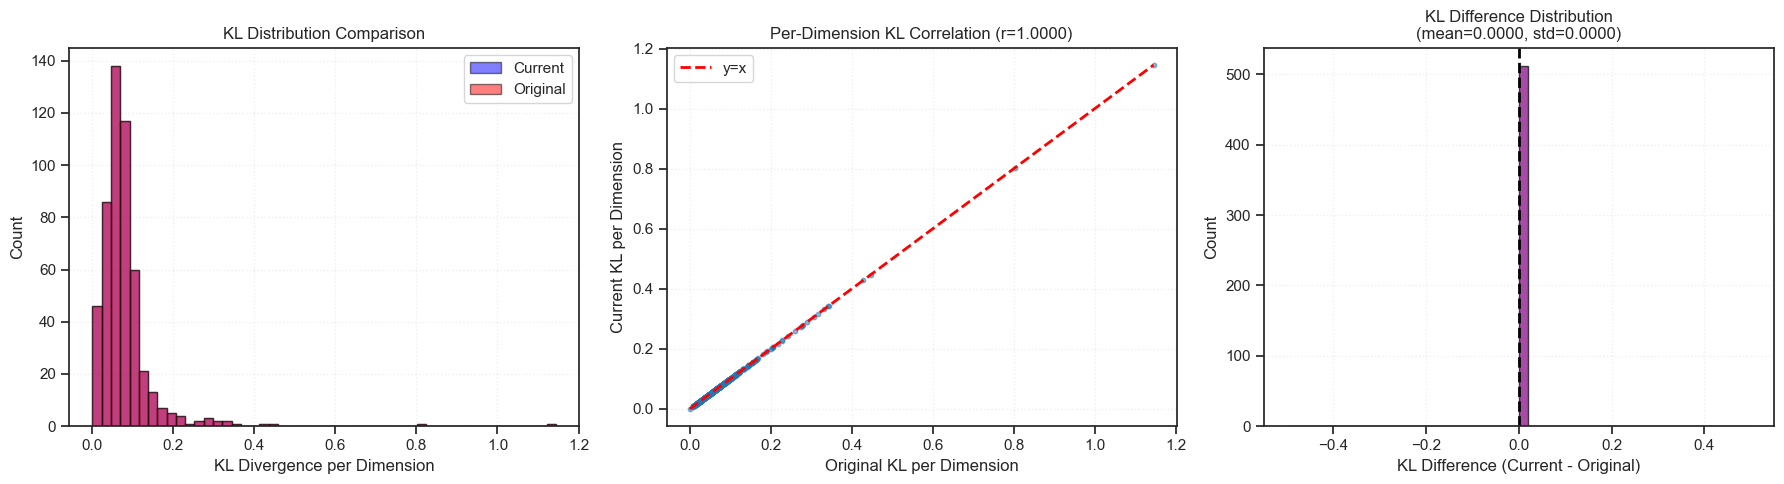


CONCLUSION
✓ Models are VERY SIMILAR - same parameters produced consistent results



In [ ]:
# Compare with Original Checkpoint
print("="*80)
print("MODEL COMPARISON: Current vs Original")
print("="*80)

# Store current model results
current_results = {
    'name': 'poisson_lin_lin (newly trained)',
    'neg_elbo': neg_elbo.item(),
    'recon_loss': recon_loss.item(),
    'kl_loss': kl_loss.item(),
    'n_active': n_active,
    'n_total': n_total,
    'active_proportion': active_proportion,
    'n_dead': n_dead_histogram,
    'lifetime_sparsity': lifetime_sparsity,
    'kl_per_dim': kl_per_dim.copy(),
}

# Load the original checkpoint
original_checkpoint_dir = Path('./checkpoints/poisson-<lin|lin>-vH16_mach-0_(2024_11_28,15:26)')
if original_checkpoint_dir.exists():
    print(f"\nLoading original checkpoint from: {original_checkpoint_dir.name}")
    
    # Create a new model instance for the original
    model_original = PoissonVAE(model_cfg)
    model_original = model_original.to(device)
    
    # Load checkpoint
    checkpoint_files_orig = sorted(original_checkpoint_dir.glob("PoissonVAE+TrainerVAE-*.pt"))
    if checkpoint_files_orig:
        checkpoint_file_orig = checkpoint_files_orig[-1]
        print(f"  Loading: {checkpoint_file_orig.name}")
        
        checkpoint_orig = torch.load(checkpoint_file_orig, map_location=device, weights_only=False)
        
        # Handle different checkpoint formats
        if isinstance(checkpoint_orig, dict):
            if 'model_state_dict' in checkpoint_orig:
                model_original.load_state_dict(checkpoint_orig['model_state_dict'])
            elif 'model' in checkpoint_orig:
                model_original.load_state_dict(checkpoint_orig['model'])
            else:
                model_original.load_state_dict(checkpoint_orig)
        else:
            model_original.load_state_dict(checkpoint_orig)
        
        print(f"  ✓ Original checkpoint loaded")
        
        # Run analysis on original model
        model_original.eval()
        with torch.no_grad():
            # Use same validation batch
            x_val = next(iter(dl_vld))[0].to(device)
            
            # Forward pass
            dist_orig, log_dr_orig, spks_orig, y_orig = model_original(x_val)
            
            # Compute KL divergence per sample and dimension
            kl_diag_orig = model_original.loss_kl(log_dr_orig)
            
            # Compute metrics
            mse_orig = torch.mean((x_val - y_orig)**2, dim=[1,2,3])
            kl_per_sample_orig = torch.sum(kl_diag_orig, dim=1)
            recon_loss_orig = torch.mean(mse_orig) * (model_original.cfg.input_sz ** 2)
            kl_loss_orig = torch.mean(kl_per_sample_orig)
            neg_elbo_orig = recon_loss_orig + kl_loss_orig
            
            # Compute KL per latent dimension
            kl_per_dim_orig = torch.mean(kl_diag_orig, dim=0).cpu().numpy()
            
            # Active neuron analysis
            active_mask_orig = kl_per_dim_orig > threshold
            n_active_orig = np.sum(active_mask_orig)
            active_proportion_orig = n_active_orig / n_total
            
            # Dead neurons
            n_dead_orig = np.sum(kl_per_dim_orig < threshold)
            
            # Lifetime sparsity
            spks_np_orig = spks_orig.cpu().numpy()
            active_per_neuron_orig = np.mean(spks_np_orig > 0, axis=0)
            lifetime_sparsity_orig = np.mean(active_per_neuron_orig)
        
        original_results = {
            'name': f'{original_checkpoint_dir.name}',
            'neg_elbo': neg_elbo_orig.item(),
            'recon_loss': recon_loss_orig.item(),
            'kl_loss': kl_loss_orig.item(),
            'n_active': n_active_orig,
            'n_total': n_total,
            'active_proportion': active_proportion_orig,
            'n_dead': n_dead_orig,
            'lifetime_sparsity': lifetime_sparsity_orig,
            'kl_per_dim': kl_per_dim_orig.copy(),
        }
        
        # Print comparison
        print("\n" + "="*80)
        print("COMPARISON TABLE")
        print("="*80)
        
        comparison_df = pd.DataFrame({
            'Current Model': [
                f"{current_results['neg_elbo']:.2f}",
                f"{current_results['recon_loss']:.2f}",
                f"{current_results['kl_loss']:.2f}",
                f"{current_results['n_active']}/{current_results['n_total']} ({current_results['active_proportion']:.2%})",
                f"{current_results['n_dead']}/{current_results['n_total']} ({current_results['n_dead']/current_results['n_total']:.2%})",
                f"{current_results['lifetime_sparsity']:.4f} ({current_results['lifetime_sparsity']*100:.2f}%)",
            ],
            'Original Model': [
                f"{original_results['neg_elbo']:.2f}",
                f"{original_results['recon_loss']:.2f}",
                f"{original_results['kl_loss']:.2f}",
                f"{original_results['n_active']}/{original_results['n_total']} ({original_results['active_proportion']:.2%})",
                f"{original_results['n_dead']}/{original_results['n_total']} ({original_results['n_dead']/original_results['n_total']:.2%})",
                f"{original_results['lifetime_sparsity']:.4f} ({original_results['lifetime_sparsity']*100:.2f}%)",
            ],
            'Difference': [
                f"{current_results['neg_elbo'] - original_results['neg_elbo']:+.2f}",
                f"{current_results['recon_loss'] - original_results['recon_loss']:+.2f}",
                f"{current_results['kl_loss'] - original_results['kl_loss']:+.2f}",
                f"{int(current_results['n_active']) - int(original_results['n_active']):+d}",
                f"{int(current_results['n_dead']) - int(original_results['n_dead']):+d}",
                f"{current_results['lifetime_sparsity'] - original_results['lifetime_sparsity']:+.4f}",
            ]
        }, index=[
            'Negative ELBO',
            'Reconstruction Loss',
            'KL Divergence',
            'Active Neurons',
            'Dead Neurons',
            'Lifetime Sparsity',
        ])
        
        print("\n")
        print(comparison_df.to_string())
        
        # Statistical comparison of KL distributions
        from scipy import stats
        kl_corr = np.corrcoef(current_results['kl_per_dim'], original_results['kl_per_dim'])[0, 1]
        kl_diff_mean = np.mean(np.abs(current_results['kl_per_dim'] - original_results['kl_per_dim']))
        kl_diff_max = np.max(np.abs(current_results['kl_per_dim'] - original_results['kl_per_dim']))
        
        print(f"\nKL Distribution Similarity:")
        print(f"  Correlation: {kl_corr:.6f}")
        print(f"  Mean absolute difference: {kl_diff_mean:.6f}")
        print(f"  Max absolute difference: {kl_diff_max:.6f}")
        
        # Visualize comparison
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # KL distribution comparison
        axes[0].hist(current_results['kl_per_dim'], bins=50, alpha=0.5, color='blue', 
                     label='Current', edgecolor='black')
        axes[0].hist(original_results['kl_per_dim'], bins=50, alpha=0.5, color='red', 
                     label='Original', edgecolor='black')
        axes[0].set_xlabel('KL Divergence per Dimension')
        axes[0].set_ylabel('Count')
        axes[0].set_title('KL Distribution Comparison')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Scatter plot: current vs original KL
        axes[1].scatter(original_results['kl_per_dim'], current_results['kl_per_dim'], 
                       alpha=0.5, s=10)
        max_kl = max(current_results['kl_per_dim'].max(), original_results['kl_per_dim'].max())
        axes[1].plot([0, max_kl], [0, max_kl], 'r--', linewidth=2, label='y=x')
        axes[1].set_xlabel('Original KL per Dimension')
        axes[1].set_ylabel('Current KL per Dimension')
        axes[1].set_title(f'Per-Dimension KL Correlation (r={kl_corr:.4f})')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # Difference plot
        kl_diff = current_results['kl_per_dim'] - original_results['kl_per_dim']
        axes[2].hist(kl_diff, bins=50, alpha=0.7, color='purple', edgecolor='black')
        axes[2].axvline(0, color='black', linestyle='--', linewidth=2)
        axes[2].set_xlabel('KL Difference (Current - Original)')
        axes[2].set_ylabel('Count')
        axes[2].set_title(f'KL Difference Distribution\n(mean={kl_diff.mean():.4f}, std={kl_diff.std():.4f})')
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Conclusion
        print("\n" + "="*80)
        print("CONCLUSION")
        print("="*80)
        
        if kl_corr > 0.95 and kl_diff_mean < 0.01:
            print("✓ Models are VERY SIMILAR - same parameters produced consistent results")
        elif kl_corr > 0.8 and kl_diff_mean < 0.05:
            print("✓ Models are SIMILAR - minor differences likely due to random initialization")
        else:
            print("⚠ Models show SIGNIFICANT DIFFERENCES - may need further investigation")
        
        print(f"\n{'='*80}")
        
    else:
        print(f"⚠ No checkpoint files found in {original_checkpoint_dir}")
else:
    print(f"\n⚠ Original checkpoint directory not found: {original_checkpoint_dir}")
    print("Available checkpoint directories:")
    for d in Path('./checkpoints').glob('*'):
        if d.is_dir():
            print(f"  - {d.name}")

INFERENCE METHOD COMPARISON

Exact (EX):
  Negative ELBO: 228.31
  Reconstruction Loss: 187.37
  KL Divergence: 40.95

Monte Carlo (MC):
  Negative ELBO: 228.80
  Reconstruction Loss: 187.85
  KL Divergence: 40.95

Straight-Through (ST):
  Negative ELBO: 228.84
  Reconstruction Loss: 187.89
  KL Divergence: 40.95

METHOD COMPARISON TABLE


                      Exact Monte Carlo Straight-Through Exact - MC Straight-Through - MC
Negative ELBO        228.31      228.80           228.84      -0.49                 +0.04
Reconstruction Loss  187.37      187.85           187.89      -0.49                 +0.04
KL Divergence         40.95       40.95            40.95      +0.00                 +0.00


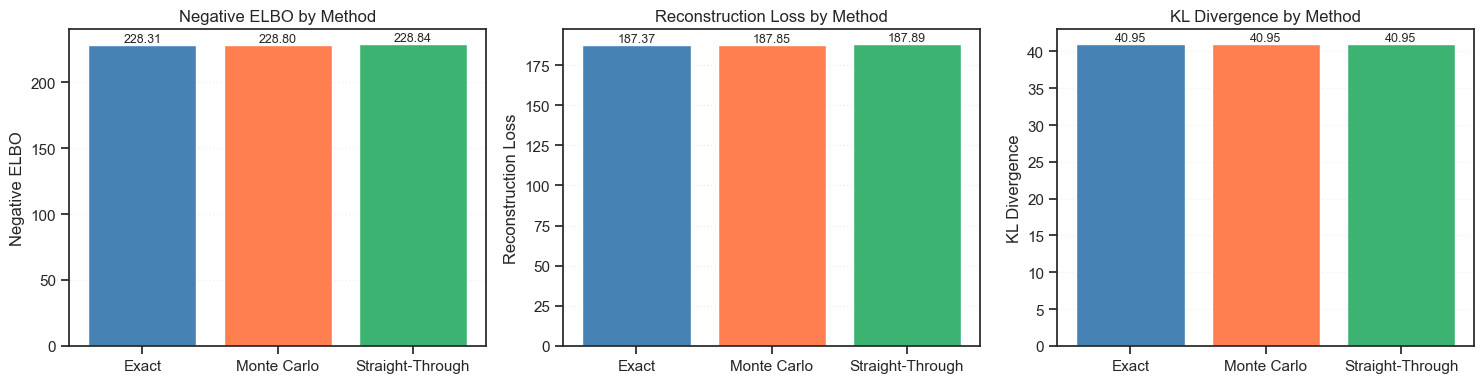


ANALYSIS

✓ All three inference methods evaluated successfully

Method characteristics:
  • Exact (EX): Uses exact Poisson PMF (most accurate, computationally expensive)
  • Monte Carlo (MC): Samples from distribution (balanced accuracy/efficiency)
  • Straight-Through (ST): Uses biased gradient estimator (fastest, may be less accurate)

Best ELBO: Exact (228.31)



In [13]:
# Compare Inference Methods: EX (Exact), MC (Monte Carlo), ST (Straight-Through)
print("="*80)
print("INFERENCE METHOD COMPARISON")
print("="*80)

model.eval()
with torch.no_grad():
    # Get a validation batch
    x_val_methods = next(iter(dl_vld))[0].to(device)
    
    # Store original method
    original_method = model.cfg.method if hasattr(model.cfg, 'method') else 'mc'
    
    methods = ['ex', 'mc', 'st']
    method_names = {
        'ex': 'Exact',
        'mc': 'Monte Carlo', 
        'st': 'Straight-Through'
    }
    
    results_methods = {}
    
    for method in methods:
        # Temporarily change the model's sampling method
        if hasattr(model, 'method'):
            model.method = method
        
        # Forward pass with specific method
        try:
            # Get distribution and sample
            dist, log_dr, spks, y = model(x_val_methods)
            
            # Compute KL divergence
            kl_diag = model.loss_kl(log_dr)
            
            # Compute metrics
            mse = torch.mean((x_val_methods - y)**2, dim=[1,2,3])
            kl_per_sample = torch.sum(kl_diag, dim=1)
            recon_loss = torch.mean(mse) * (model.cfg.input_sz ** 2)
            kl_loss = torch.mean(kl_per_sample)
            neg_elbo = recon_loss + kl_loss
            
            results_methods[method] = {
                'neg_elbo': neg_elbo.item(),
                'recon_loss': recon_loss.item(),
                'kl_loss': kl_loss.item(),
                'mse_mean': torch.mean(mse).item(),
                'kl_mean': torch.mean(kl_per_sample).item()
            }
            
            print(f"\n{method_names[method]} ({method.upper()}):")
            print(f"  Negative ELBO: {neg_elbo.item():.2f}")
            print(f"  Reconstruction Loss: {recon_loss.item():.2f}")
            print(f"  KL Divergence: {kl_loss.item():.2f}")
            
        except Exception as e:
            print(f"\n{method_names[method]} ({method.upper()}): Failed - {str(e)}")
            results_methods[method] = None
    
    # Restore original method
    if hasattr(model, 'method'):
        model.method = original_method

# Create comparison table
print("\n" + "="*80)
print("METHOD COMPARISON TABLE")
print("="*80)

valid_methods = {k: v for k, v in results_methods.items() if v is not None}

if len(valid_methods) > 0:
    comparison_data = {
        method_names[method]: [
            f"{results['neg_elbo']:.2f}",
            f"{results['recon_loss']:.2f}",
            f"{results['kl_loss']:.2f}",
        ]
        for method, results in valid_methods.items()
    }
    
    # Add difference columns if we have multiple methods
    if len(valid_methods) > 1:
        # Use MC as baseline
        if 'mc' in valid_methods:
            baseline = valid_methods['mc']
            for method, results in valid_methods.items():
                if method != 'mc':
                    comparison_data[f'{method_names[method]} - MC'] = [
                        f"{results['neg_elbo'] - baseline['neg_elbo']:+.2f}",
                        f"{results['recon_loss'] - baseline['recon_loss']:+.2f}",
                        f"{results['kl_loss'] - baseline['kl_loss']:+.2f}",
                    ]
    
    comparison_methods_df = pd.DataFrame(
        comparison_data,
        index=['Negative ELBO', 'Reconstruction Loss', 'KL Divergence']
    )
    
    print("\n")
    print(comparison_methods_df.to_string())
    
    # Visualize comparison
    if len(valid_methods) > 1:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        methods_list = list(valid_methods.keys())
        colors = ['steelblue', 'coral', 'mediumseagreen']
        
        # ELBO comparison
        elbo_vals = [valid_methods[m]['neg_elbo'] for m in methods_list]
        bars = axes[0].bar([method_names[m] for m in methods_list], elbo_vals, color=colors[:len(methods_list)])
        axes[0].set_ylabel('Negative ELBO')
        axes[0].set_title('Negative ELBO by Method')
        axes[0].grid(True, alpha=0.3, axis='y')
        for bar, val in zip(bars, elbo_vals):
            height = bar.get_height()
            axes[0].text(bar.get_x() + bar.get_width()/2., height,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=9)
        
        # Reconstruction Loss comparison
        recon_vals = [valid_methods[m]['recon_loss'] for m in methods_list]
        bars = axes[1].bar([method_names[m] for m in methods_list], recon_vals, color=colors[:len(methods_list)])
        axes[1].set_ylabel('Reconstruction Loss')
        axes[1].set_title('Reconstruction Loss by Method')
        axes[1].grid(True, alpha=0.3, axis='y')
        for bar, val in zip(bars, recon_vals):
            height = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=9)
        
        # KL Divergence comparison
        kl_vals = [valid_methods[m]['kl_loss'] for m in methods_list]
        bars = axes[2].bar([method_names[m] for m in methods_list], kl_vals, color=colors[:len(methods_list)])
        axes[2].set_ylabel('KL Divergence')
        axes[2].set_title('KL Divergence by Method')
        axes[2].grid(True, alpha=0.3, axis='y')
        for bar, val in zip(bars, kl_vals):
            height = bar.get_height()
            axes[2].text(bar.get_x() + bar.get_width()/2., height,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.show()
    
    # Analysis
    print("\n" + "="*80)
    print("ANALYSIS")
    print("="*80)
    
    if len(valid_methods) == 3:
        print("\n✓ All three inference methods evaluated successfully")
        print("\nMethod characteristics:")
        print("  • Exact (EX): Uses exact Poisson PMF (most accurate, computationally expensive)")
        print("  • Monte Carlo (MC): Samples from distribution (balanced accuracy/efficiency)")
        print("  • Straight-Through (ST): Uses biased gradient estimator (fastest, may be less accurate)")
        
        # Find best method
        best_elbo_method = min(valid_methods.items(), key=lambda x: x[1]['neg_elbo'])
        print(f"\nBest ELBO: {method_names[best_elbo_method[0]]} ({best_elbo_method[1]['neg_elbo']:.2f})")
    
else:
    print("\n⚠ No valid method results to compare")

print(f"\n{'='*80}")

Decoder Weights:


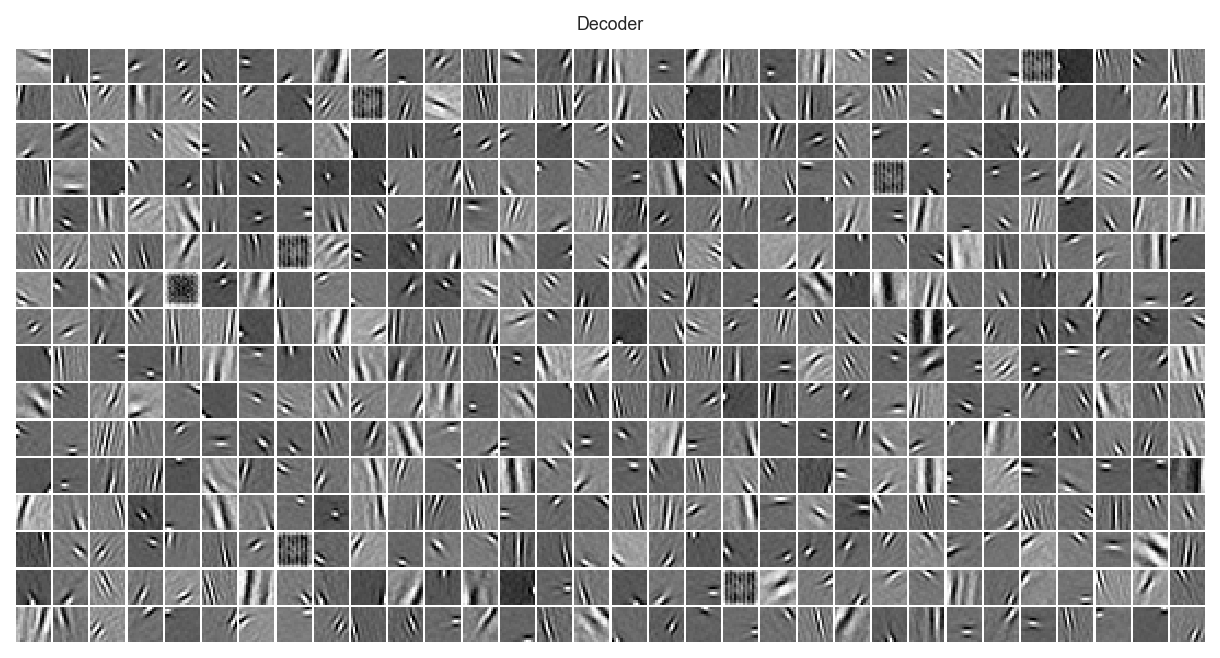


Encoder Weights:


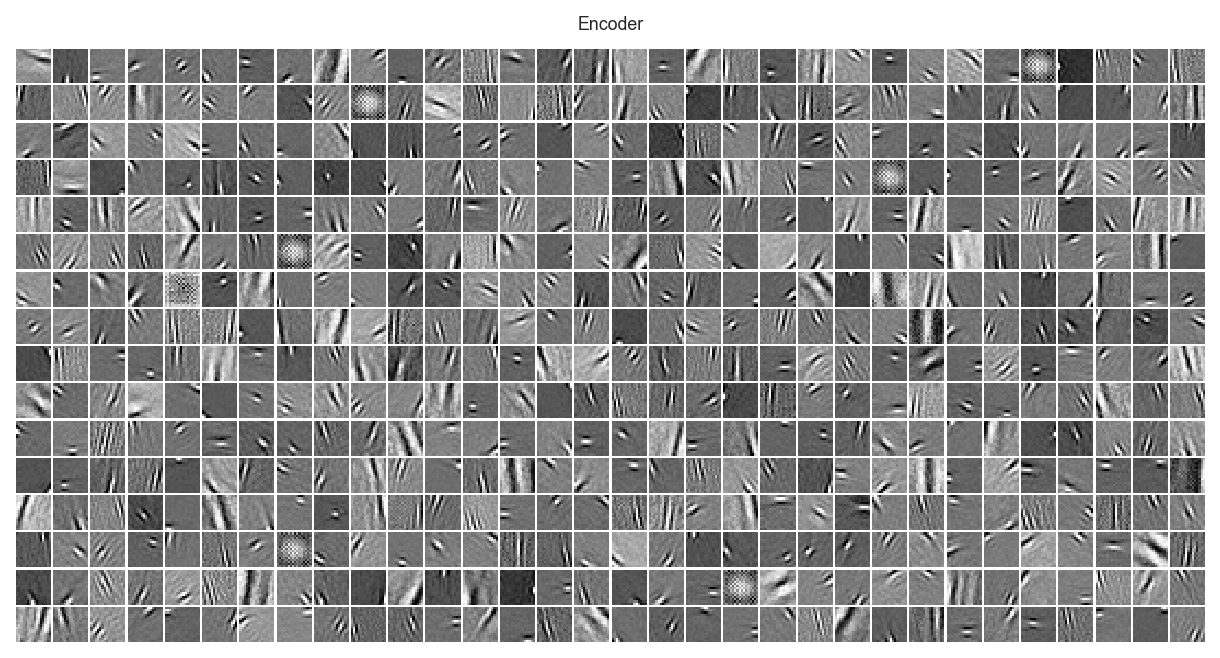

In [13]:
# Display decoder and encoder weights using model.show()
import matplotlib.pyplot as plt

# Show decoder weights
print("Decoder Weights:")
fig_dec, ax_dec = model.show(which='dec', add_title=True, display=True)
plt.show()

# Show encoder weights
print("\nEncoder Weights:")
fig_enc, ax_enc = model.show(which='enc', add_title=True, display=True)
plt.show()

In [ ]:
# Train new model with updated distributions.py in sweeping folder
print("="*80)
print("TRAINING NEW MODEL WITH UPDATED DISTRIBUTIONS")
print("="*80)

# Update configuration for sweeping run
EPOCHS_SWEEP = 3000
CHECKPOINT_PATH_SWEEP = "./checkpoints/sweeping"
SCHEDULER_KWS_SWEEP = {"T_max": 2995.0, "eta_min": 1e-05}

print(f"\nConfiguration for sweeping run:")
print(f"  Checkpoint path: {CHECKPOINT_PATH_SWEEP}")
print(f"  Epochs: {EPOCHS_SWEEP} (reduced from {EPOCHS})")
print(f"  Using updated distributions.py with new Poisson class")

# Create new model configuration
model_cfg_sweep = ConfigPoisVAE(
    prior_clamp=PRIOR_CLAMP,
    prior_log_dist=PRIOR_LOG_DIST,
    hard_fwd=HARD_FWD,
    exc_only=EXC_ONLY,
    rmax_q=RMAX_Q,
    dataset=DATASET,
    n_ch=N_CH,
    n_latents=N_LATENTS,
    enc_type=ENC_TYPE,
    dec_type=DEC_TYPE,
    enc_bias=ENC_BIAS,
    dec_bias=DEC_BIAS,
    enc_norm=ENC_NORM,
    dec_norm=DEC_NORM,
    fit_prior=FIT_PRIOR,
    activation_fn=ACTIVATION_FN,
    init_dist=INIT_DIST,
    init_scale=INIT_SCALE,
    res_eps=RES_EPS,
    use_bn=USE_BN,
    use_se=USE_SE,
    seed=SEED,
    save=False,
    base_dir=CHECKPOINT_DIR,
    data_dir=DATA_DIR,
)

# Update the checkpoint directory
model_cfg_sweep.mods_dir = CHECKPOINT_PATH_SWEEP

# Create training configuration
train_cfg_sweep = ConfigTrainVAE(
    method=METHOD,
    kl_beta=KL_BETA,
    kl_beta_min=KL_BETA_MIN,
    kl_anneal_cycles=KL_ANNEAL_CYCLES,
    kl_anneal_portion=KL_ANNEAL_PORTION,
    kl_const_portion=KL_CONST_PORTION,
    lambda_anneal=LAMBDA_ANNEAL,
    lambda_init=LAMBDA_INIT,
    lambda_norm=LAMBDA_NORM,
    temp_anneal_portion=TEMP_ANNEAL_PORTION,
    temp_anneal_type=TEMP_ANNEAL_TYPE,
    temp_start=TEMP_START,
    temp_stop=TEMP_STOP,
    lr=LEARNING_RATE,
    epochs=EPOCHS_SWEEP,
    batch_size=BATCH_SIZE,
    warm_restart=WARM_RESTART,
    warmup_epochs=WARMUP_EPOCHS,
    optimizer=OPTIMIZER,
    optimizer_kws=OPTIMIZER_KWS,
    scheduler_type=SCHEDULER_TYPE,
    scheduler_kws=SCHEDULER_KWS_SWEEP,
    ema_rate=EMA_RATE,
    grad_clip=GRAD_CLIP,
    use_amp=USE_AMP,
    chkpt_freq=EPOCHS_SWEEP,
    eval_freq=EVAL_FREQ,
    log_freq=LOG_FREQ,
)

print(f"\n✓ Configurations created")
print(f"  Model config: {model_cfg_sweep.enc_type}|{model_cfg_sweep.dec_type}")
print(f"  Training: {train_cfg_sweep.epochs} epochs")

TRAINING NEW MODEL WITH UPDATED DISTRIBUTIONS

Configuration for sweeping run:
  Checkpoint path: ./checkpoints/sweeping
  Epochs: 1500 (reduced from 3000)
  Using updated distributions.py with new Poisson class

✓ Configurations created
  Model config: lin|lin
  Training: 1500 epochs


In [16]:
# Initialize new model with updated distributions
model_sweep = PoissonVAE(model_cfg_sweep)
model_sweep = model_sweep.to(device)

# Override the create_chkpt_dir method to use sweeping directory
def simple_chkpt_dir_sweep(self, fit_name=None):
    self.chkpt_dir = CHECKPOINT_PATH_SWEEP
    os.makedirs(self.chkpt_dir, exist_ok=True)

model_sweep.create_chkpt_dir = lambda fit_name=None: simple_chkpt_dir_sweep(model_sweep, fit_name)

# Count parameters
n_params_sweep = sum(p.numel() for p in model_sweep.parameters() if p.requires_grad)
print(f"✓ Model initialized on {device}")
print(f"  Trainable parameters: {n_params_sweep:,}")
print(f"  Same as original model: {n_params_sweep == n_params}")

# Show model architecture
print(f"\nModel Architecture:")
print(f"  Encoder output: {model_sweep._enc_out_channel()} features")
print(f"  Decoder input: {model_sweep._dec_in_channel()} features")
print(f"  Output shape: {model_sweep.shape}")

✓ Model initialized on cuda:0
  Trainable parameters: 262,656
  Same as original model: True

Model Architecture:
  Encoder output: 512 features
  Decoder input: 512 features
  Output shape: (-1, 1, 16, 16)


In [18]:
# Initialize trainer and train the model
trainer_sweep = TrainerVAE(
    model=model_sweep,
    cfg=train_cfg_sweep,
    device=device,
    verbose=True,
)

print(f"✓ Trainer initialized")
print(f"  Total iterations: {trainer_sweep.n_iters}")
print(f"  Iterations per epoch: {len(trainer_sweep.dl_trn)}")

print(f"\nStarting training for {EPOCHS_SWEEP} epochs...")
print(f"This will take some time...")

# Train the model
trainer_sweep.train()

print(f"\n✓ Training complete!")
print(f"  Model saved to: {CHECKPOINT_PATH_SWEEP}")


# params: 262.7 K
✓ Trainer initialized
  Total iterations: 120000
  Iterations per epoch: 80

Starting training for 1500 epochs...
This will take some time...


epoch # 1500, avg loss: 175.491640: 100%|██████████| 1500/1500 [27:44<00:00,  1.11s/it]


✓ Training complete!
  Model saved to: ./checkpoints/sweeping


LEARNED WEIGHTS FROM SWEEPING MODEL (with updated distributions)

Decoder Weights:


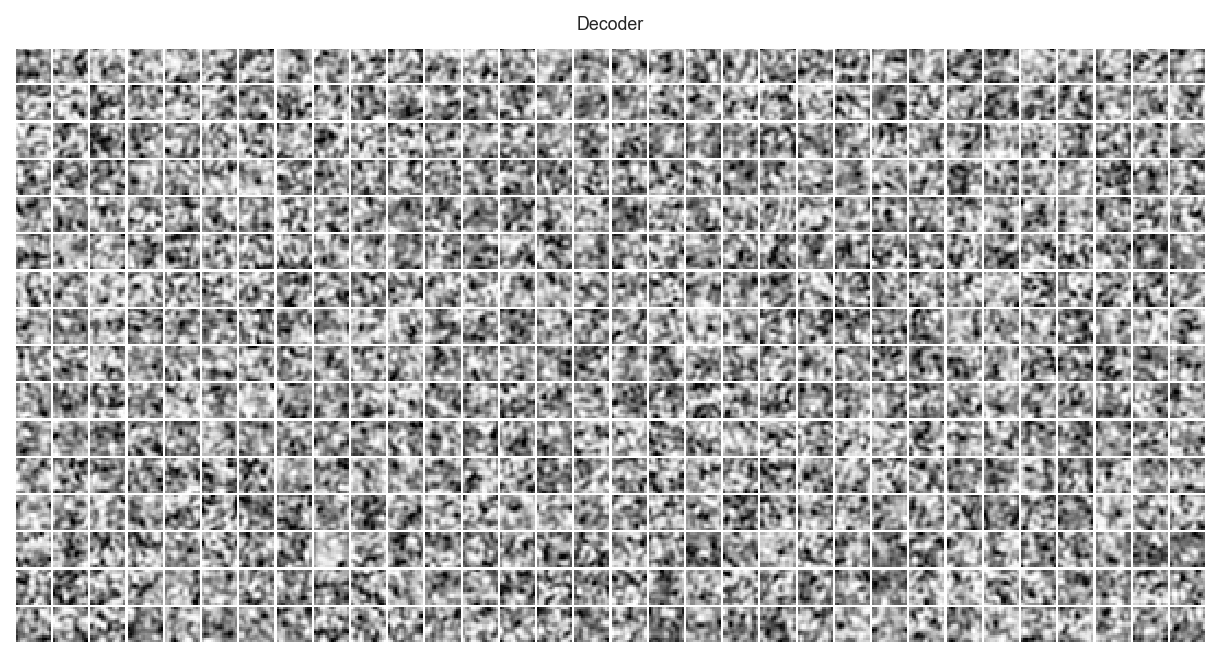


Encoder Weights:


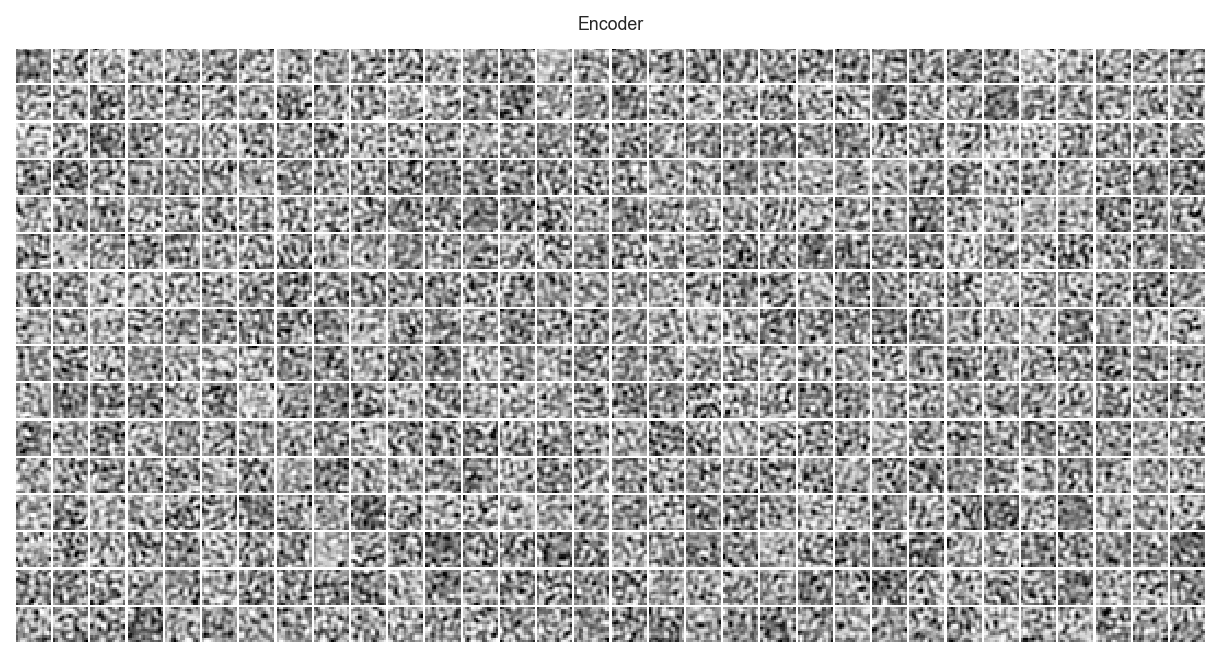


COMPARISON
Compare these with the original poisson_lin_lin model weights shown earlier.
Both models should learn similar Gabor-like filter dictionaries if the
updated distributions.py produces the same learning dynamics.


In [19]:
# Display the learned weights from the new model
print("="*80)
print("LEARNED WEIGHTS FROM SWEEPING MODEL (with updated distributions)")
print("="*80)

# Show decoder weights
print("\nDecoder Weights:")
fig_dec_sweep, ax_dec_sweep = model_sweep.show(which='dec', add_title=True, display=True)
plt.show()

# Show encoder weights
print("\nEncoder Weights:")
fig_enc_sweep, ax_enc_sweep = model_sweep.show(which='enc', add_title=True, display=True)
plt.show()

print("\n" + "="*80)
print("COMPARISON")
print("="*80)
print("Compare these with the original poisson_lin_lin model weights shown earlier.")
print("Both models should learn similar Gabor-like filter dictionaries if the")
print("updated distributions.py produces the same learning dynamics.")